In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from requests import head

In [6]:
tickers = ["AAPL", "TSLA", "MSFT", "GOOGL", "AMZN"]

stocks = {}

for ticker in tickers:
    stocks[ticker] = pd.read_csv(f"../data/{ticker}.csv", index_col=0, parse_dates=True, skiprows=[1,2])
    print(f"{ticker} loaded successfully")

AAPL loaded successfully
TSLA loaded successfully
MSFT loaded successfully
GOOGL loaded successfully
AMZN loaded successfully


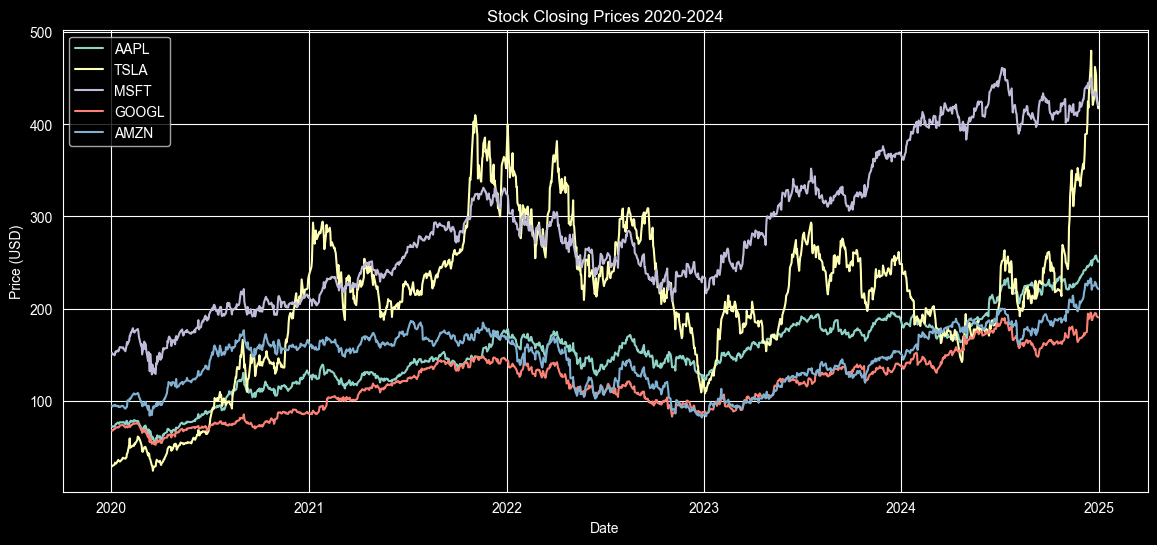

In [7]:
plt.figure(figsize=(14, 6))

returns = pd.DataFrame()

for ticker in tickers:
    plt.plot(stocks[ticker].index, stocks[ticker]["Close"], label=ticker)

plt.title("Stock Closing Prices 2020-2024")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

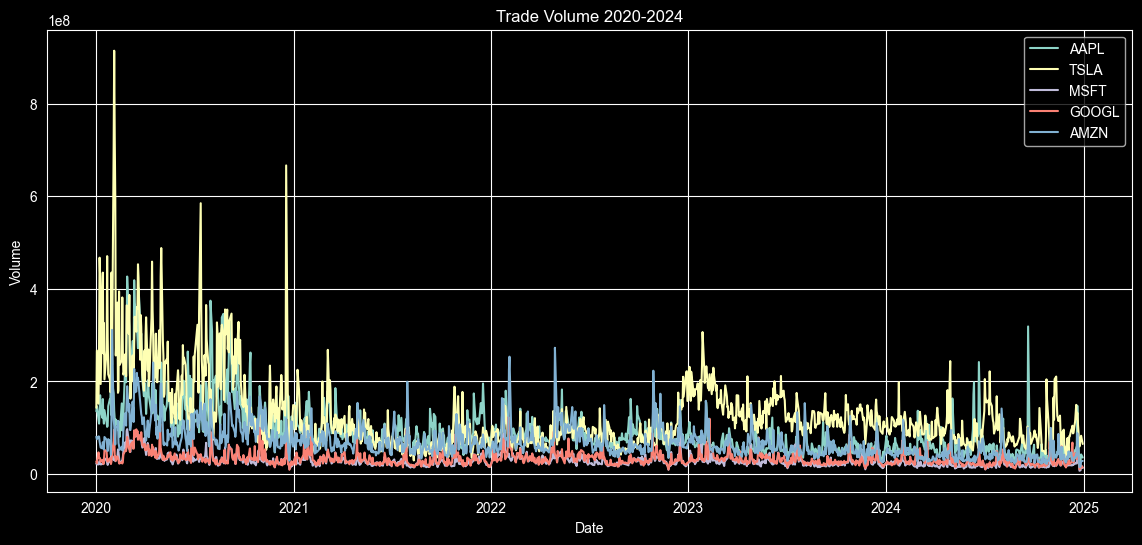

In [8]:
plt.figure(figsize=(14,6))


for ticker in tickers:
  plt.plot(stocks[ticker].index, stocks[ticker]["Volume"], label=ticker)

plt.title("Trade Volume 2020-2024")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.grid(True)
plt.show()



In [9]:
returns = pd.DataFrame()

for ticker in tickers:
    returns[ticker] = stocks[ticker]["Close"].pct_change()

print(returns.shape)
print(returns.head())

(1257, 5)
                AAPL      TSLA      MSFT     GOOGL      AMZN
Price                                                       
2020-01-02       NaN       NaN       NaN       NaN       NaN
2020-01-03 -0.009722  0.029633 -0.012452 -0.005231 -0.012139
2020-01-06  0.007968  0.019255  0.002585  0.026654  0.014886
2020-01-07 -0.004703  0.038801 -0.009118 -0.001932  0.002092
2020-01-08  0.016087  0.049205  0.015928  0.007118 -0.007809


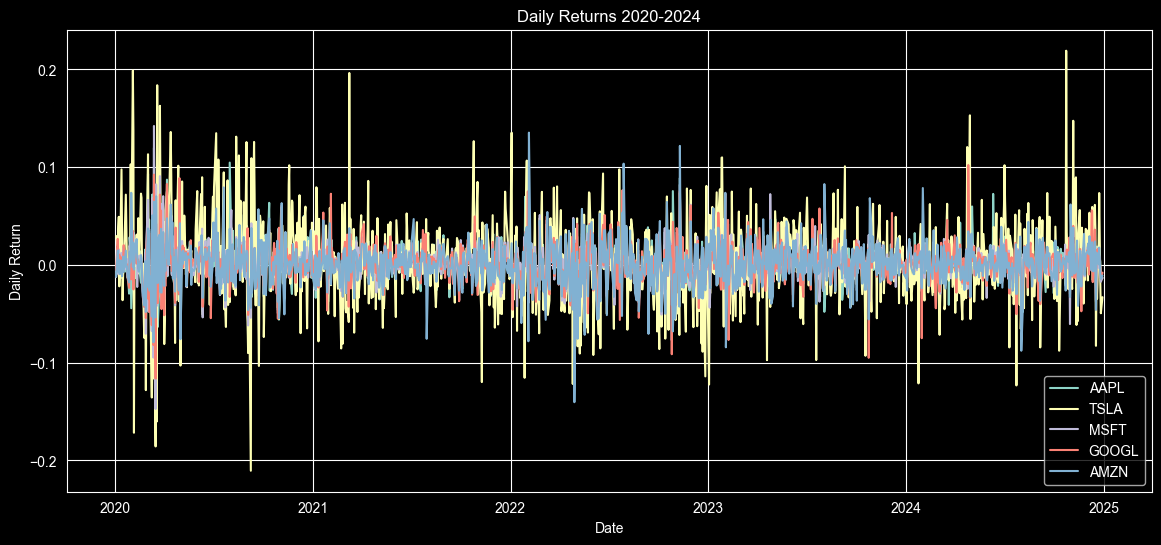

In [10]:
plt.figure(figsize=(14, 6))

for ticker in tickers :
    plt.plot(stocks[ticker].index, returns[ticker], label=ticker)

plt.title("Daily Returns 2020-2024")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.grid(True)
plt.show()

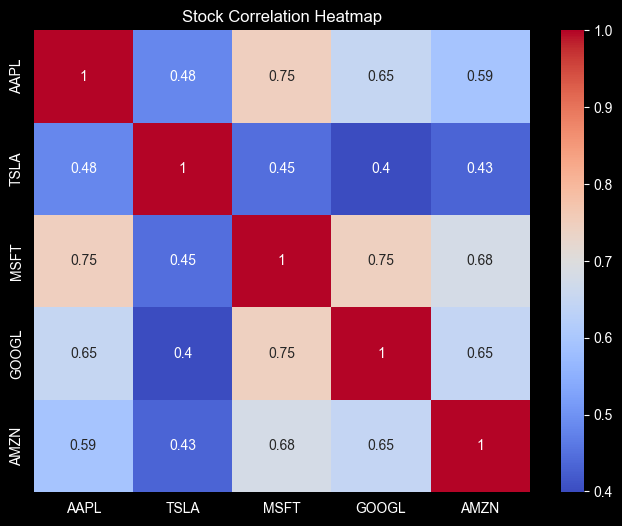

In [11]:
plt.figure(figsize=(8,6))

sns.heatmap(returns.corr(), annot=True, cmap="coolwarm")
plt.title("Stock Correlation Heatmap")
plt.show()


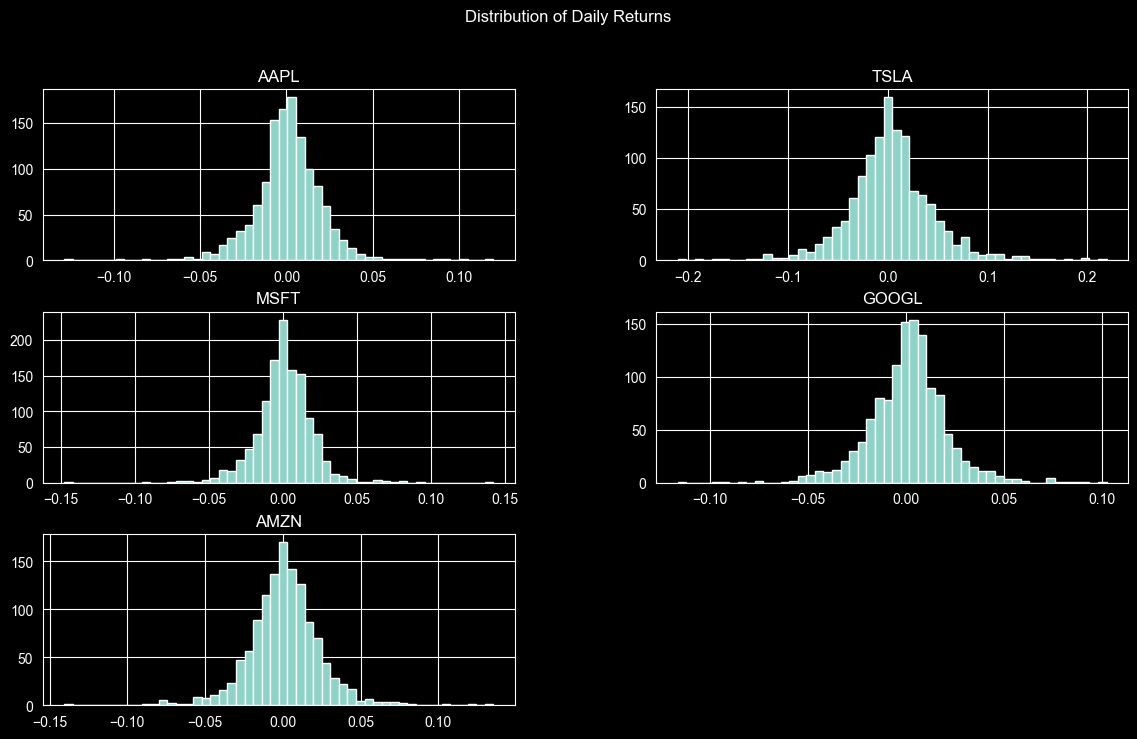

In [12]:
returns.hist(figsize=(14, 8), bins=50)
plt.suptitle("Distribution of Daily Returns")
plt.show()